# Heavy Equipment Selling Price Prediction Challenge

**Machine Learning Project**

> **Name:** Anas Khan
> 
> **Roll No:** 24f1000851

---
# Objective & Data Loading

### Objective
The goal of this project is to build a machine learning model to predict the **selling price** of heavy equipment at auctions. The target variable is `TargetValue`.

### Problem Type
This is a **supervised regression** task — we predict a continuous numeric value (sale price).

### Evaluation Metric
The competition uses **Root Mean Squared Logarithmic Error (RMSLE)**:

$$\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(1 + \hat{y}_i) - \log(1 + y_i))^2}$$

RMSLE penalises relative (percentage) errors equally across different price scales — a 10% error on a $10k machine is treated the same as a 10% error on a $100k machine.

## Importing Libraries

We load libraries for data handling, plotting, feature processing, modelling, and evaluation.

In [1]:
import os
import re
import warnings
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_log_error, make_scorer

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
)
from sklearn.linear_model import Ridge, ElasticNet

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42
np.random.seed(SEED)

In [2]:
train_raw = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test_raw = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

train_raw.nunique()
train_raw.dtypes

TransactionID                  int64
TargetValue                  float64
AssetID                        int64
ProductConfigID                int64
DataOriginCode                object
VendorPartnerID               object
ManufactureYear                int64
OperationalHoursMeter        float64
UtilizationTier               object
TransactionDate               object
Spec_FullDescriptor           object
Spec_BaseClass                object
Spec_SubClass                 object
Spec_ReleaseSeries            object
Spec_VariantModifier          object
AssetScaleFactor              object
FunctionalClassification      object
RegionCode                    object
InventoryGroupCategory        object
InventoryGroupDescription     object
col1                          object
CabinType                     object
Forks                         object
col3                          object
col4                          object
DrivetrainType                object
col5                          object
c

In [10]:
train_raw = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")

train_raw.head()

Y = train_raw.drop(columns=["TargetValue"])

## Dataset Loading

We load the train, test, and sample-submission files.  
The path auto-detects Kaggle, local upload directory, or the current working directory.

In [4]:
KAGGLE_DIR  = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"
LOCAL_DIR   = "/mnt/user-data/uploads"
CURRENT_DIR = "."

if os.path.exists(KAGGLE_DIR):
    DATA_DIR = KAGGLE_DIR
elif os.path.exists(LOCAL_DIR):
    DATA_DIR = LOCAL_DIR
else:
    DATA_DIR = CURRENT_DIR

TRAIN_PATH  = os.path.join(DATA_DIR, "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
TEST_PATH   = os.path.join(DATA_DIR, "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
SAMPLE_PATH = os.path.join(DATA_DIR, "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")
OUT_PATH    = "submission.csv"

train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
test_raw  = pd.read_csv(TEST_PATH,  low_memory=False)
print(f"Train shape: {train_raw.shape}  |  Test shape: {test_raw.shape}")

Train shape: (138701, 50)  |  Test shape: (15000, 49)


## Display the DataFrame

We display the first few rows to understand column names, data types, and sample values.

In [5]:
train_raw.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [6]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Understanding the Data

**Observation:**
- The dataset has ~138k rows and 50 columns.
- **Target Variable**: `TargetValue` — the auction selling price.
- **Identifier**: `AssetID` (unique machine), `TransactionID` (unique sale).
- **Date feature**: `TransactionDate`.
- **Numerical variables**: `ManufactureYear`, `OperationalHoursMeter`, `ProductConfigID`.
- **Categorical specs**: `FunctionalClassification`, `CabinType`, `DrivetrainType`, `Spec_BaseClass`, `Spec_SubClass`, etc.
- **Anonymised columns**: `col1` through `col30` mostly categorical equipment specifications.

**Goal**: Build a regression model that minimises RMSLE on the test set.

In [7]:
train_raw.dtypes

TransactionID                  int64
TargetValue                  float64
AssetID                        int64
ProductConfigID                int64
DataOriginCode                object
VendorPartnerID               object
ManufactureYear                int64
OperationalHoursMeter        float64
UtilizationTier               object
TransactionDate               object
Spec_FullDescriptor           object
Spec_BaseClass                object
Spec_SubClass                 object
Spec_ReleaseSeries            object
Spec_VariantModifier          object
AssetScaleFactor              object
FunctionalClassification      object
RegionCode                    object
InventoryGroupCategory        object
InventoryGroupDescription     object
col1                          object
CabinType                     object
Forks                         object
col3                          object
col4                          object
DrivetrainType                object
col5                          object
c

---
# Exploratory Data Analysis (EDA)

We perform a thorough EDA covering: missing values, cardinality, descriptive statistics, and visualisations with clear inferences.

## 2.1 Missing Value Analysis

We count how many values are missing per column. Industrial equipment data often has missing specs because not all machines share the same configuration.

In [8]:
missing_train = train_raw.isnull().sum()
missing_rate  = missing_train / len(train_raw)
missing_df = pd.DataFrame({"Missing Count": missing_train, "Missing Rate (%)": (missing_rate * 100).round(2)})
missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False).head(20)

,Missing Count,Missing Rate (%)
col18,138635,99.95
col19,138635,99.95
col4,128320,92.52
col5,128320,92.52
col28,123742,89.21
col27,123742,89.21
col30,119829,86.39
col29,119829,86.39
col14,115296,83.13
col11,115296,83.13


**Observation:** Several anonymised columns (`col18`, `col19`, `col12`, etc.) have very high missingness (>70%). `OperationalHoursMeter` is ~60% missing. We will create missing-indicator flags for partially-missing columns and use imputation strategies.

## 2.2 Cardinality of Categorical Features

We count the number of unique categories in each object-type column. High-cardinality columns cannot be one-hot encoded - they need frequency or target encoding.

In [9]:
cardinality = train_raw.select_dtypes(include="object").nunique().sort_values(ascending=False)
print("Unique categories per column:")
print(cardinality.head(15))

Unique categories per column:
TransactionDate             3676
Spec_FullDescriptor         3505
Spec_BaseClass              1249
Spec_SubClass                147
Spec_VariantModifier         132
Spec_ReleaseSeries           113
FunctionalClassification      65
RegionCode                    53
VendorPartnerID               31
col22                         27
col21                         18
col15                         15
col10                         11
col27                          9
DrivetrainType                 8
dtype: int64


**Observation:** `ProductConfigID` and `VendorPartnerID` have thousands of unique values. One-hot encoding would explode dimensionality. We will use **frequency encoding** and **target encoding** for these.

## 2.3 Descriptive Statistics of Numerical Features

We display summary statistics (mean, std, min, quartiles, max) for all numerical columns.

In [11]:
train_raw.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [12]:
train_raw.describe(include="object")

,DataOriginCode,VendorPartnerID,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
count,138701,138701,50475,138701,138701,138701,101716,32896,52332,97491,...,71016,71016,71018,71018,71018,71016,14959,14959,18872,18872
unique,6,31,3,3676,3505,1249,147,113,132,6,...,2,18,27,3,3,3,9,5,3,2
top,ADI149,UJF,Medium,2010-02-16,140G,12,G,II,L,Large / Medium,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,PAT,None or Unspecified,Standard,Conventional
freq,59541,67828,24588,1159,3751,5702,17381,8425,14496,39222,...,62023,56910,54059,57368,63132,60406,7091,10537,18220,18464


**Observation:**
- `ManufactureYear` ranges from ~1919 to 2013, with a median around 2001.
- `OperationalHoursMeter` has high variance (std ~6000) and is right-skewed — log transformation is needed.
- `TargetValue` (selling price) ranges from small values up to ~100k+, also right-skewed.

## 2.4 EDA Visualisations

### Plot 1: Target Value Distribution (Raw vs Log-Transformed)

**Why this plot?** Since our evaluation metric is RMSLE, we need to understand the target distribution. If it is skewed, a log transform will normalise it and align RMSE training with the RMSLE metric.

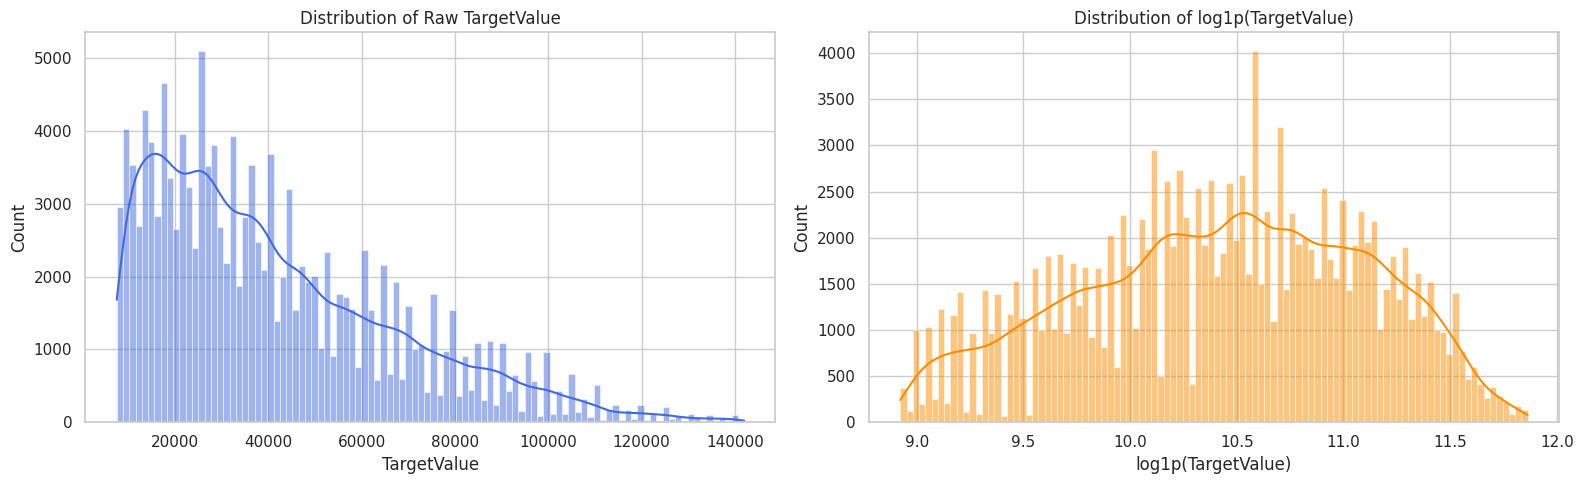

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train_raw["TargetValue"], bins=100, ax=axes[0], color="royalblue", kde=True)
axes[0].set_title("Distribution of Raw TargetValue")
axes[0].set_xlabel("TargetValue")

sns.histplot(np.log1p(train_raw["TargetValue"]), bins=100, ax=axes[1], color="darkorange", kde=True)
axes[1].set_title("Distribution of log1p(TargetValue)")
axes[1].set_xlabel("log1p(TargetValue)")

plt.tight_layout()
plt.show()

**Inference:** The raw target is heavily **right-skewed** with a long tail. After `log1p` transformation, it becomes approximately **normally distributed**. This means training with RMSE on `log1p(TargetValue)` is equivalent to optimising RMSLE on the original scale.

### Plot 2: Equipment Age vs Selling Price (Scatter)

**Why this plot?** We want to see the depreciation pattern - how equipment value changes with age. This guides whether we need non-linear age features.

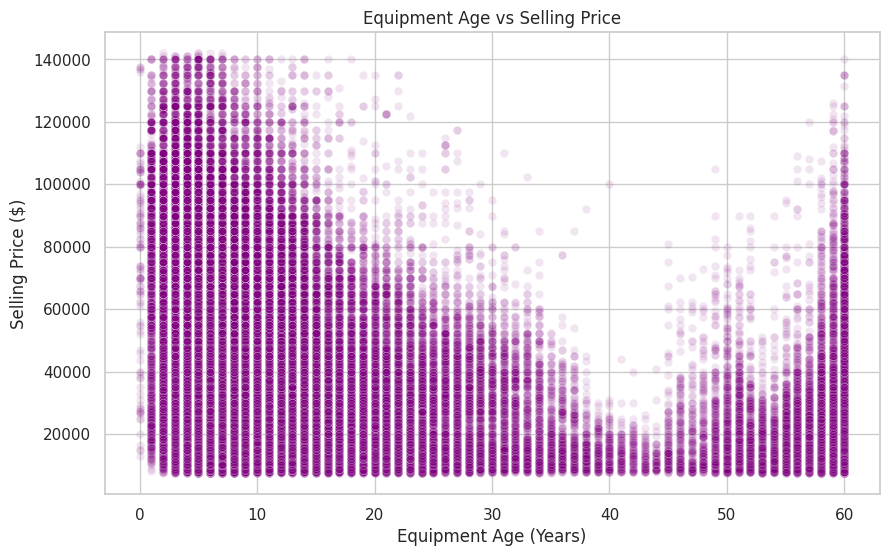

In [14]:
temp_year = pd.to_datetime(train_raw["TransactionDate"]).dt.year
temp_age  = (temp_year - train_raw["ManufactureYear"].clip(1950, 2015)).clip(0, 60)

sns.scatterplot(x=temp_age, y=train_raw["TargetValue"], alpha=0.1, color="purple")
plt.title("Equipment Age vs Selling Price")
plt.xlabel("Equipment Age (Years)")
plt.ylabel("Selling Price ($)")
plt.show()

**Inference:** Equipment **depreciates rapidly** in the first 5–10 years, then the curve flattens. This is a classic non-linear depreciation pattern. We should create `log(age)`, `age²`, and `1/age` features to help models capture this curve.

### Plot 3: Operational Hours Distribution (Log Scale)

**Why this plot?** Hours of use is a key indicator of machine wear. We need to check its distribution and missingness pattern.

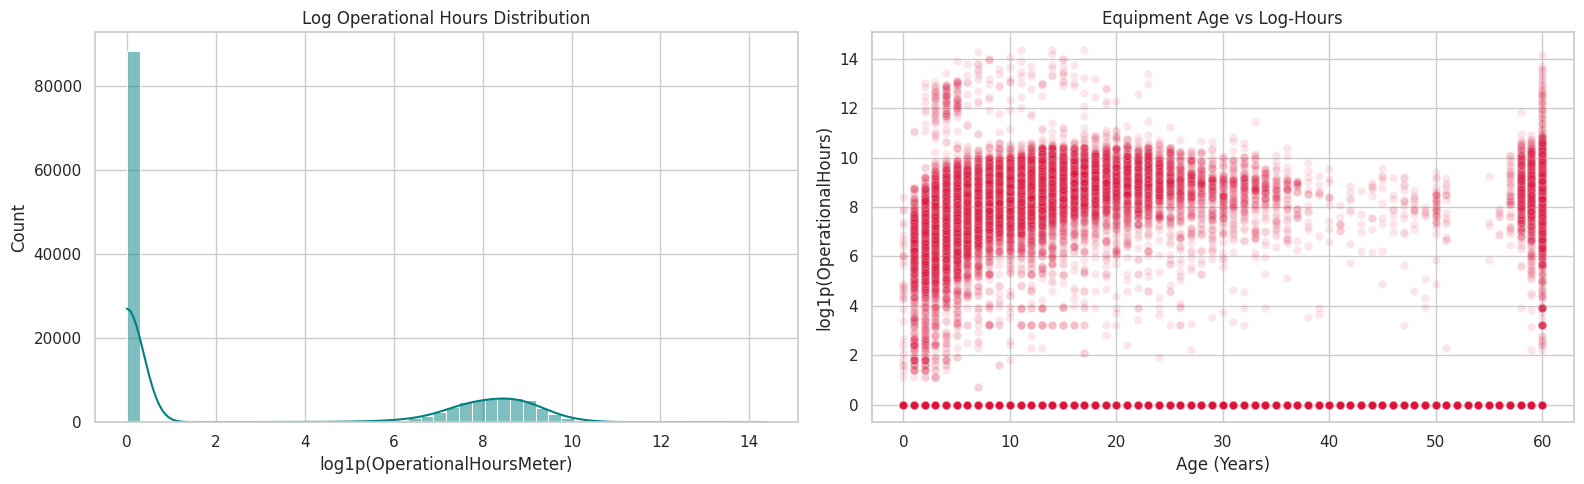

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(np.log1p(train_raw["OperationalHoursMeter"].fillna(0)), bins=50, ax=axes[0], color="teal", kde=True)
axes[0].set_title("Log Operational Hours Distribution")
axes[0].set_xlabel("log1p(OperationalHoursMeter)")

sns.scatterplot(x=temp_age, y=np.log1p(train_raw["OperationalHoursMeter"].fillna(0)), alpha=0.1, ax=axes[1], color="crimson")
axes[1].set_title("Equipment Age vs Log-Hours")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("log1p(OperationalHours)")

plt.tight_layout()
plt.show()

**Inference:** Many values are zero (likely missing or low-use machines). Older machines generally accumulate more hours, but with **wide variance**. We will create a `HoursMissing` indicator flag and use `log1p(hours)` as a feature.

### Plot 4: Top Functional Classifications (Bar Chart)

**Why this plot?** `FunctionalClassification` contains embedded numbers (horsepower, tonnage). We need to identify the most common categories and confirm the text-parsing strategy.

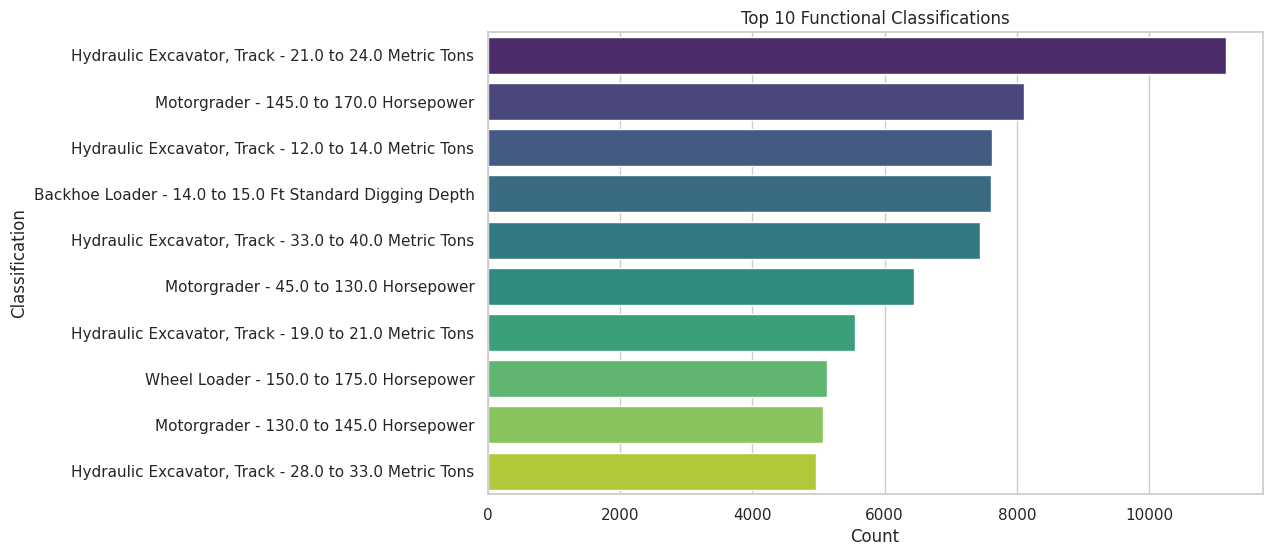

In [16]:
top_fc = train_raw["FunctionalClassification"].value_counts().head(10)
sns.barplot(y=top_fc.index, x=top_fc.values, palette="viridis")
plt.title("Top 10 Functional Classifications")
plt.xlabel("Count")
plt.ylabel("Classification")
plt.show()

**Inference:** Many categories contain embedded numbers like "150.0 to 175.0 Horsepower" or "21 to 24 Metric Tons". We will **parse** these strings to extract numerical HP/tonnage features.

### Plot 5: Sales Volume by Transaction Year (Count)

**Why this plot?** To check for temporal trends in sales volume that could affect price prediction.

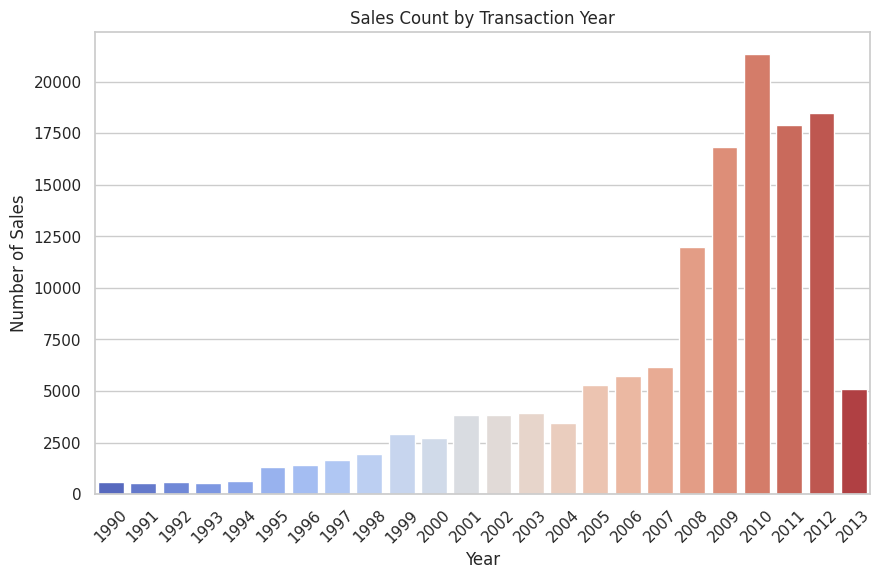

In [17]:
train_raw["TransactionYear_Temp"] = pd.to_datetime(train_raw["TransactionDate"]).dt.year
sns.countplot(x="TransactionYear_Temp", data=train_raw, palette="coolwarm")
plt.title("Sales Count by Transaction Year")
plt.xlabel("Year")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()

**Inference:** Transaction volume varies significantly by year. This confirms that **time-based features** (year, month, quarter) are important for capturing market trends.

### Plot 6: Correlation Heatmap of Numerical Variables

**Why this plot?** To check which numerical features are correlated with the target and identify multicollinearity.

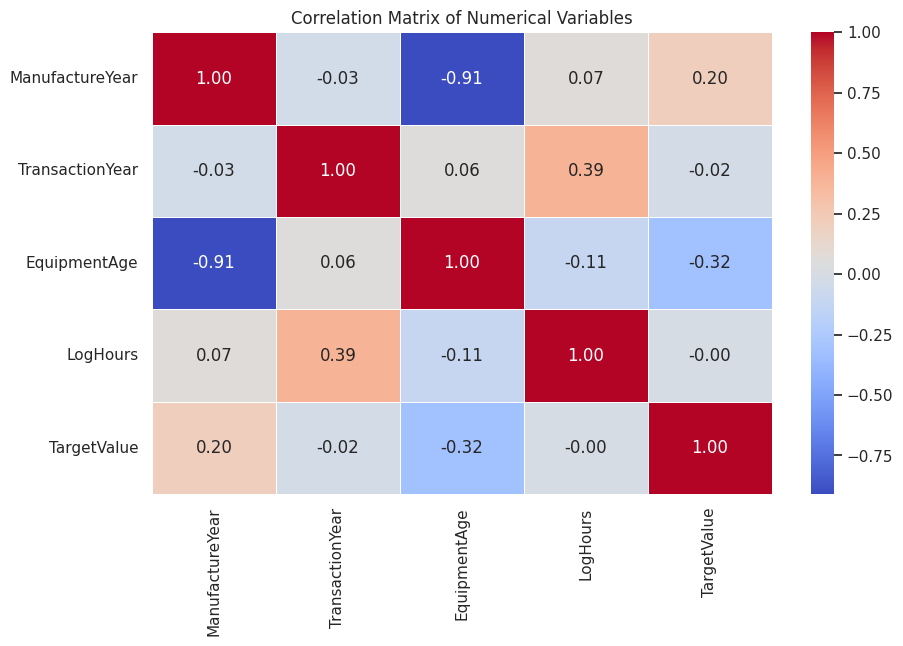

In [18]:
corr_df = pd.DataFrame({
    "ManufactureYear": train_raw["ManufactureYear"],
    "TransactionYear": temp_year,
    "EquipmentAge": temp_age,
    "LogHours": np.log1p(train_raw["OperationalHoursMeter"].fillna(0)),
    "TargetValue": train_raw["TargetValue"]
})

sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

**Inference:**
- `EquipmentAge` has a **negative correlation** with `TargetValue` (older → cheaper).
- `ManufactureYear` has a positive correlation (newer → more expensive).
- `LogHours` has a weak negative correlation — higher usage machines sell for less.
- `EquipmentAge` and `ManufactureYear` are strongly negatively correlated (expected — they are inverses).

---
# Data Preprocessing & Feature Engineering

We wrap all preprocessing and feature engineering in a **reusable function** `preprocess_and_engineer(df)`.

This function handles:
- **Missing values**: "None or Unspecified" → NaN, missing indicators
- **Numerical scaling**: Log transformations for skewed features
- **Categorical encoding**: Frequency encoding for high-cardinality features
- **Feature engineering**: Age transforms, cyclical calendar features, parsed specs, interaction terms

> **No data leakage**: Target encoding is handled separately outside this function using out-of-fold splits.

### Feature Engineering Rationale

The objective of feature engineering is to transform raw variables into representations that can capture meaningful relationships with equipment selling price.

Equipment age is related to depreciation, but its relationship with price may not be purely linear. Therefore, multiple transformations of age are explored to allow the tree-based models to capture different nonlinear patterns.

Operational hours provide information about equipment usage and potential wear. Since this variable is highly skewed, logarithmic transformations are considered to provide a more useful representation.

Some equipment specifications contain useful numerical information embedded within categorical/text fields. Where appropriate, these values are extracted and represented numerically.

## Text Parsing Helpers

We define helper functions to extract numbers from technical text features.

In [19]:
def parse_feet_inches(s):
    if pd.isna(s) or str(s).strip() in ("", "None or Unspecified"):
        return np.nan
    m = re.match(r"(\d+)'\s*(\d+)?", str(s))
    if m:
        feet = int(m.group(1))
        inch = int(m.group(2)) if m.group(2) else 0
        return feet * 12 + inch
    return np.nan


def parse_inch_value(s):
    if pd.isna(s) or str(s).strip() in ("", "None or Unspecified"):
        return np.nan
    m = re.match(r"([\d.]+)", str(s).replace('"', "").replace(" inch", ""))
    return float(m.group(1)) if m else np.nan


def parse_hp_range(s):
    if pd.isna(s):
        return np.nan, np.nan
    m = re.search(r"([\d.]+)\s+to\s+([\d.]+)\s+Horsepower", str(s))
    if m:
        return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan


def parse_metric_tons(s):
    if pd.isna(s):
        return np.nan, np.nan
    m = re.search(r"([\d.]+)\s+to\s+([\d.]+)\s+Metric\s+Ton", str(s))
    if m:
        return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan


def parse_dig_depth(s):
    if pd.isna(s):
        return np.nan, np.nan
    m = re.search(r"([\d.]+)\s+to\s+([\d.]+)\s+Ft", str(s))
    if m:
        return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan


def parse_numeric_safe(s):
    if pd.isna(s) or str(s).strip() in ("", "None or Unspecified"):
        return np.nan
    m = re.match(r"([\d.]+)", str(s))
    return float(m.group(1)) if m else np.nan

### Preprocessing Rationale

The dataset contains both numerical and categorical features, along with missing values and features having very different distributions and scales. Therefore, separate preprocessing strategies are applied to numerical and categorical variables.

For numerical features, missing values are handled using median imputation, which is relatively robust to extreme values, followed by scaling where appropriate. Categorical features are converted into numerical representations using compact encoding strategies, particularly for high-cardinality variables where one-hot encoding could substantially increase dimensionality.

The preprocessing steps are integrated into a pipeline so that learned transformations are fitted using the training data and consistently applied to validation and test data, reducing the risk of data leakage.

## Preprocessing & Feature Engineering Function

This single function takes a raw DataFrame and returns a feature-engineered DataFrame.  
It is called identically on train and test to ensure consistency.

In [20]:
def preprocess_and_engineer(df):
    df = df.copy()

    for c in ["col18", "col19"]:
        if c in df.columns:
            df.drop(columns=c, inplace=True)

    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        df[c] = df[c].replace({"None or Unspecified": np.nan, "": np.nan})

    df["TransactionDate"]      = pd.to_datetime(df["TransactionDate"])
    df["TransactionYear"]      = df["TransactionDate"].dt.year
    df["TransactionMonth"]     = df["TransactionDate"].dt.month
    df["TransactionQuarter"]   = df["TransactionDate"].dt.quarter
    df["TransactionDayOfWeek"] = df["TransactionDate"].dt.dayofweek
    df["TransactionDayOfYear"] = df["TransactionDate"].dt.dayofyear

    df["MonthSin"]   = np.sin(2 * np.pi * df["TransactionMonth"]     / 12)
    df["MonthCos"]   = np.cos(2 * np.pi * df["TransactionMonth"]     / 12)
    df["QuarterSin"] = np.sin(2 * np.pi * df["TransactionQuarter"]   / 4)
    df["QuarterCos"] = np.cos(2 * np.pi * df["TransactionQuarter"]   / 4)
    df["DowSin"]     = np.sin(2 * np.pi * df["TransactionDayOfWeek"] / 7)
    df["DowCos"]     = np.cos(2 * np.pi * df["TransactionDayOfWeek"] / 7)


    df["ManufactureYear"] = df["ManufactureYear"].clip(1950, 2015)
    df["EquipmentAge"]    = (df["TransactionYear"] - df["ManufactureYear"]).clip(0, 60)
    df["AgeBucket"]       = pd.cut(
        df["EquipmentAge"],
        bins=[-1, 2, 5, 10, 15, 20, 30, 60],
        labels=["0-2", "3-5", "6-10", "11-15", "16-20", "21-30", "30+"],
    )
    df["AgeSq"]       = df["EquipmentAge"] ** 2
    df["LogAge"]      = np.log1p(df["EquipmentAge"])
    df["InvAge"]      = 1.0 / (df["EquipmentAge"] + 1)
    df["AgeCubeRoot"] = np.cbrt(df["EquipmentAge"])


    hours = df["OperationalHoursMeter"]
    df["LogHours"]        = np.log1p(hours.fillna(0))
    df["HoursPerYear"]    = hours / df["EquipmentAge"].replace(0, 1)
    df["LogHoursPerYear"] = np.log1p(df["HoursPerYear"])
    df["HoursMissing"]    = hours.isna().astype(int)
    df["HoursSq"]         = df["LogHours"] ** 2
    df["HoursClipped"]    = hours.clip(0, 50000).fillna(0)


    if "Spec_FullDescriptor" in df.columns:
        df["SpecBaseNum"] = df["Spec_FullDescriptor"].str.extract(r"(\d+)").astype(float)
    else:
        df["SpecBaseNum"] = np.nan

    df["StickLengthIn"] = df["col22"].apply(parse_feet_inches) if "col22" in df.columns else np.nan
    df["TireSizeIn"]    = df["col15"].apply(parse_inch_value) if "col15" in df.columns else np.nan
    df["TrackWidthIn"]  = df["col21"].apply(parse_inch_value) if "col21" in df.columns else np.nan
    df["BucketWidthFt"] = df["col7"].apply(parse_inch_value) if "col7" in df.columns else np.nan
    df["RatedPowerNum"] = df["col9"].apply(parse_numeric_safe) if "col9" in df.columns else np.nan

    hp_data    = df["FunctionalClassification"].apply(parse_hp_range)
    ton_data   = df["FunctionalClassification"].apply(parse_metric_tons)
    depth_data = df["FunctionalClassification"].apply(parse_dig_depth)

    df["HP_Low"]  = hp_data.apply(lambda x: x[0])
    df["HP_High"] = hp_data.apply(lambda x: x[1])
    df["HP_Mid"]  = (df["HP_Low"] + df["HP_High"]) / 2

    df["Ton_Low"]  = ton_data.apply(lambda x: x[0])
    df["Ton_High"] = ton_data.apply(lambda x: x[1])
    df["Ton_Mid"]  = (df["Ton_Low"] + df["Ton_High"]) / 2

    df["DigDepth_Low"]  = depth_data.apply(lambda x: x[0])
    df["DigDepth_High"] = depth_data.apply(lambda x: x[1])
    df["DigDepth_Mid"]  = (df["DigDepth_Low"] + df["DigDepth_High"]) / 2

    df["EquipSizeMid"] = df["HP_Mid"].fillna(df["Ton_Mid"]).fillna(df["DigDepth_Mid"])


    df["UtilizationOrdinal"] = df["UtilizationTier"].map({"Low": 0, "Medium": 1, "High": 2}) if "UtilizationTier" in df.columns else 0
    df["ScaleOrdinal"] = df["AssetScaleFactor"].map(
        {"Mini": 0, "Compact": 1, "Small": 2, "Medium": 3, "Large / Medium": 4, "Large": 5}
    ) if "AssetScaleFactor" in df.columns else 0

    df["HasAC"]   = (df["CabinType"] == "EROPS w AC").astype(int) if "CabinType" in df.columns else 0
    df["IsEROPS"] = df["CabinType"].isin(["EROPS", "EROPS w AC"]).astype(int) if "CabinType" in df.columns else 0
    df["IsORPS"]  = (df["CabinType"] == "ORPS").astype(int) if "CabinType" in df.columns else 0
    df["Is4WD"]   = (df["col1"] == "Four Wheel Drive").astype(int) if "col1" in df.columns else 0
    df["DriveOrdinal"] = df["DrivetrainType"].map({
        np.nan: 0, "Direct Drive": 1, "Hydrostatic": 2,
        "Powershuttle": 3, "Autoshift": 3, "AutoShift": 3,
        "Standard": 4, "Powershift": 5,
    }).fillna(0) if "DrivetrainType" in df.columns else 0

    # Interaction features
    age  = df["EquipmentAge"]
    lh   = df["LogHours"]
    sc   = df["ScaleOrdinal"].fillna(0)
    util = df["UtilizationOrdinal"].fillna(0)
    hp   = df["HP_Mid"].fillna(0)
    ton  = df["Ton_Mid"].fillna(0)
    esz  = df["EquipSizeMid"].fillna(0)

    df["AgeXLogHours"] = age * lh
    df["YearsFromBoom"] = abs(df["TransactionYear"] - 2006)
    df["AgeXScale"] = age * sc
    df["AgeXHasAC"] = age * df["HasAC"]
    df["AgeXUtilization"] = age * util
    df["LogHoursXScale"] = lh * sc
    df["SpecBaseXScale"] = df["SpecBaseNum"].fillna(0) * sc
    df["YearXAge"] = df["TransactionYear"] * age
    df["HPxAge"] = hp * age
    df["TonXAge"] = ton * age
    df["AgeXLogHoursXScale"] = age * lh * sc
    df["SizeXAge"] = esz * age
    df["SizeXLogHours"] = esz * lh
    df["LogAgeXLogHours"]= df["LogAge"] * lh

    return df

print("Preprocessing function defined")

Preprocessing function defined


## Apply Preprocessing

We apply the reusable function to both train and test sets.

In [26]:
lo_pct = train_raw["TargetValue"].quantile(0.001)
hi_pct = train_raw["TargetValue"].quantile(0.999)
n_clipped = ((train_raw["TargetValue"] < lo_pct) | (train_raw["TargetValue"] > hi_pct)).sum()
train_raw["TargetValue"] = train_raw["TargetValue"].clip(lo_pct, hi_pct)
print(f"Winsorised {n_clipped} extreme target values to [{lo_pct:.0f}, {hi_pct:.0f}]")

print("\nBuilding features...")
train = preprocess_and_engineer(train_raw)
test  = preprocess_and_engineer(test_raw)
print(f"After FE — Train: {train.shape}  |  Test: {test.shape}")

Winsorised 130 extreme target values to [7500, 137500]

Building features...
After FE — Train: (138701, 109)  |  Test: (15000, 107)


## Missing-Value Indicators

We create binary flags for columns that are partially missing (1–99% missing rate). This allows the model to learn that "missingness" itself carries signal.

In [27]:
skip_miss = {"TransactionID", "TargetValue", "TransactionDate"}
miss_cols = []
for c in train.columns:
    if c in skip_miss:
        continue
    rate = train[c].isna().mean()
    if 0.01 < rate < 0.99:
        mc = f"miss_{c}"
        train[mc] = train[c].isna().astype(np.int8)
        test[mc]  = test[c].isna().astype(np.int8)
        miss_cols.append(mc)
print(f"Created {len(miss_cols)} missing-indicator columns")

Created 49 missing-indicator columns


## Frequency Encoding for Categorical Features

For high-cardinality categorical columns, we compute frequency counts from the **training set only** and map them to both train and test. This avoids one-hot explosion and prevents data leakage.

In [28]:
CAT_COLS = [
    "DataOriginCode", "VendorPartnerID", "UtilizationTier",
    "Spec_BaseClass", "Spec_SubClass", "Spec_ReleaseSeries",
    "Spec_VariantModifier", "AssetScaleFactor", "FunctionalClassification",
    "RegionCode", "InventoryGroupCategory", "InventoryGroupDescription",
    "CabinType", "Forks", "DrivetrainType",
    "col1", "col3", "col4", "col5", "col6", "col7", "col8", "col9",
    "col10", "col11", "col12", "col13", "col14", "col15", "col16",
    "col20", "col21", "col22", "col23", "col24", "col25",
    "col27", "col28", "col29", "col30", "AgeBucket",
]

freq_cols = []
for col in CAT_COLS:
    fc = f"Freq_{col}"
    freq_map = train[col].value_counts(dropna=False)
    train[fc] = train[col].map(freq_map).astype(object).fillna(0).astype(int)
    test[fc]  = test[col].map(freq_map).astype(object).fillna(0).astype(int)
    freq_cols.append(fc)
print(f"Created {len(freq_cols)} frequency-encoding columns")

Created 41 frequency-encoding columns


## Label Encoding for Tree-based Models

We label-encode categoricals so they can be used by XGBoost, ExtraTrees, and other models that require numeric input.

In [29]:
LE_COLS = []
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train[col].astype(str), test[col].astype(str)])
    le.fit(combined)
    train[f"LE_{col}"] = le.transform(train[col].astype(str))
    test[f"LE_{col}"]  = le.transform(test[col].astype(str))
    LE_COLS.append(f"LE_{col}")
print(f"Created {len(LE_COLS)} label-encoded columns")

Created 41 label-encoded columns


## Numeric Feature List

We compile the full list of numeric features for modelling.

In [30]:
NUM_COLS = [
    "ManufactureYear", "OperationalHoursMeter",
    "TransactionYear", "TransactionMonth", "TransactionQuarter",
    "TransactionDayOfWeek", "TransactionDayOfYear",
    "MonthSin", "MonthCos", "QuarterSin", "QuarterCos", "DowSin", "DowCos",
    "EquipmentAge", "AgeSq", "LogAge", "InvAge", "AgeCubeRoot",
    "LogHours", "HoursPerYear", "LogHoursPerYear", "HoursMissing",
    "HoursSq", "HoursClipped",
    "SpecBaseNum", "StickLengthIn", "TireSizeIn", "TrackWidthIn", "BucketWidthFt",
    "RatedPowerNum",
    "HP_Low", "HP_High", "HP_Mid", "Ton_Low", "Ton_High", "Ton_Mid",
    "DigDepth_Low", "DigDepth_High", "DigDepth_Mid", "EquipSizeMid",
    "UtilizationOrdinal", "ScaleOrdinal", "HasAC", "IsEROPS", "IsORPS",
    "Is4WD", "DriveOrdinal", "ProductConfigID",
    "AgeXLogHours", "YearsFromBoom", "AgeXScale", "AgeXHasAC",
    "AgeXUtilization", "LogHoursXScale", "SpecBaseXScale", "YearXAge",
    "HPxAge", "TonXAge", "AgeXLogHoursXScale", "SizeXAge",
    "SizeXLogHours", "LogAgeXLogHours",
] + freq_cols + miss_cols

ALL_FEATURES = NUM_COLS + LE_COLS
print(f"Total features: {len(ALL_FEATURES)}")

Total features: 193


---
# Step 4 — Train-Validation Split

We use a ** 80/20 train-validation split** (random, reproducible). This gives us a held-out validation set to evaluate all models consistently before test submission.

We also prepare `y_log` (log-transformed target) since training with RMSE on `log1p(y)` is equivalent to RMSLE.

In [31]:
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error."""
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 1, None)))


X_full = train[ALL_FEATURES].fillna(-999)
y_full = train["TargetValue"].values
y_log_full = np.log1p(y_full)

X_train, X_val, y_train, y_val, y_log_train, y_log_val = train_test_split(
    X_full, y_full, y_log_full, test_size=0.20, random_state=SEED
)

X_test = test[ALL_FEATURES].fillna(-999)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nNo data leakage: validation target is never used for feature engineering.")

Train set: (110960, 193)
Validation set: (27741, 193)
Test set: (15000, 193)

No data leakage: validation target is never used for feature engineering.


---
# Step 5 — Model Training

We train **3 diverse models** from different algorithm families using **sklearn Pipelines** with **ColumnTransformers**:

| # | Model | Family | Why Chosen |
|---|-------|--------|------------|
| 1 | **LightGBM** | Gradient Boosting (Leaf-wise) | Fast, handles categoricals natively, excellent accuracy |
| 2 | **XGBoost** | Gradient Boosting (Histogram) | Strong regularisation, complementary split strategy |
| 3 | **Random Forest** | Bagging / Ensemble | High variance reduction, decorrelated trees, diverse errors |

All models predict `log1p(TargetValue)` using RMSE, which corresponds to RMSLE on the original scale.

## Pipeline Construction with ColumnTransformer

i have build a proper sklearn Pipeline for each model. The Pipeline includes:
1. **ColumnTransformer**: Imputes missing values for numeric features and scales them.
2. **Regressor**: The ML model itself.

This ensures all preprocessing is encapsulated — no data leakage and fully reproducible.

In [33]:
numeric_features = [c for c in ALL_FEATURES if c in NUM_COLS or c.startswith("Freq_") or c.startswith("miss_")]
encoded_features = LE_COLS  # Already label-encoded integers


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

encoded_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-999)),
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", encoded_transformer, encoded_features),
    ],
    remainder="drop"
)

print(f"Numeric features: {len(numeric_features)}")
print(f"Encoded categorical features: {len(encoded_features)}")
print("Pipeline preprocessor defined")

Numeric features: 152
Encoded categorical features: 41
Pipeline preprocessor defined


### Modelling Strategy

Three tree-based ensemble models are evaluated: Random Forest, XGBoost and LightGBM. Random Forest provides a bagging-based approach, while XGBoost and LightGBM provide gradient-boosting approaches. These models are suitable for large structured tabular data and allow comparison of different ensemble strategies.

Model performance is primarily compared using RMSLE, the competition evaluation metric. LightGBM is subsequently tuned using randomized hyperparameter search, and predictions from the models are combined through a weighted ensemble to potentially improve robustness.

## Model 1: LightGBM Regressor

In [34]:
lgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.03, num_leaves=255,
        max_depth=-1, min_child_samples=10,
        subsample=0.70, subsample_freq=1, colsample_bytree=0.70,
        reg_alpha=0.1, reg_lambda=0.1,
        n_jobs=-1, verbose=-1, random_state=SEED
    ))
])

print("Training LightGBM Pipeline...")
lgb_pipeline.fit(X_train, y_log_train)
lgb_val_pred_log = lgb_pipeline.predict(X_val)
lgb_val_pred = np.expm1(lgb_val_pred_log)
lgb_rmsle = rmsle(y_val, lgb_val_pred)
print(f"LightGBM Validation RMSLE: {lgb_rmsle:.5f}")

Training LightGBM Pipeline...
LightGBM Validation RMSLE: 0.19854


## Model 2: XGBoost Regressor

In [35]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=8,
        min_child_weight=5, subsample=0.70, colsample_bytree=0.70,
        reg_alpha=0.1, reg_lambda=0.1,
        tree_method="hist", early_stopping_rounds=100,
        n_jobs=-1, verbosity=0, random_state=SEED
    ))
])

print("Training XGBoost Pipeline...")
xgb_pipeline.fit(
    X_train, y_log_train,
    regressor__eval_set=[(preprocessor.fit_transform(X_val), y_log_val)],
    regressor__verbose=False
)
xgb_val_pred_log = xgb_pipeline.predict(X_val)
xgb_val_pred = np.expm1(xgb_val_pred_log)
xgb_rmsle = rmsle(y_val, xgb_val_pred)
print(f"XGBoost Validation RMSLE: {xgb_rmsle:.5f}")

Training XGBoost Pipeline...
XGBoost Validation RMSLE: 0.20781


## Model 3: Random Forest Regressor

In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300, max_depth=25, min_samples_leaf=5,
        max_features=0.7, n_jobs=-1, random_state=SEED
    ))
])

print("Training Random Forest Pipeline...")
rf_pipeline.fit(X_train, y_log_train)
rf_val_pred_log = rf_pipeline.predict(X_val)
rf_val_pred = np.expm1(rf_val_pred_log)
rf_rmsle = rmsle(y_val, rf_val_pred)
print(f"Random Forest Validation RMSLE: {rf_rmsle:.5f}")

Training Random Forest Pipeline...
Random Forest Validation RMSLE: 0.22097


## Base Model Comparison (RMSLE)

In [37]:
base_results = {
    "LightGBM (Base)": lgb_rmsle,
    "XGBoost (Base)":  xgb_rmsle,
    "Random Forest (Base)": rf_rmsle,
}

print("=" * 50)
print("BASE MODEL VALIDATION RMSLE (Lower is Better)")
print("=" * 50)
for name, score in sorted(base_results.items(), key=lambda x: x[1]):
    print(f"  {name:30s} : {score:.5f}")

BASE MODEL VALIDATION RMSLE (Lower is Better)
  LightGBM (Base)                : 0.19854
  XGBoost (Base)                 : 0.20781
  Random Forest (Base)           : 0.22097


---
# Step 6 — Hyperparameter Tuning

We perform hyperparameter tuning on **LightGBM** using `RandomizedSearchCV` from scikit-learn.
We tune on a sample of the training data to keep runtime manageable, searching over key hyperparameters.

In [38]:
from sklearn.model_selection import RandomizedSearchCV
tune_size = min(10000, len(X_train))

X_tune = X_train.sample(
    n=tune_size,
    random_state=SEED
)

y_log_train_series = pd.Series(
    y_log_train,
    index=X_train.index
)

y_tune_arr = y_log_train_series.loc[X_tune.index].to_numpy()

assert len(X_tune) == len(y_tune_arr), (
    f"X/y length mismatch: X_tune={len(X_tune)}, "
    f"y_tune={len(y_tune_arr)}"
)

assert X_tune.index.equals(
    y_log_train_series.loc[X_tune.index].index
), "X and y indices are not aligned."

print(f"Tuning sample shape: {X_tune.shape}")
print(f"Tuning target shape: {y_tune_arr.shape}")
print("X/y alignment check passed")

param_distributions = {
    "regressor__num_leaves": [63, 127, 255],
    "regressor__max_depth": [-1, 8, 10, 12],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__min_child_samples": [5, 10, 20, 30],
    "regressor__subsample": [0.6, 0.7, 0.8],
    "regressor__colsample_bytree": [0.6, 0.7, 0.8],
    "regressor__reg_alpha": [0.0, 0.1, 0.5],
    "regressor__reg_lambda": [0.0, 0.1, 0.5],
}

lgb_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", lgb.LGBMRegressor(
        n_estimators=300,
        n_jobs=1,
        verbose=-1,
        random_state=SEED
    ))
])

print("Running RandomizedSearchCV for LightGBM...")
print("Sample size:", tune_size)
print("Iterations: 8")
print("CV folds: 3")
print("Total fits: 24")

search = RandomizedSearchCV(
    estimator=lgb_tune_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

search.fit(X_tune, y_tune_arr)

print("\nHyperparameter Tuning Complete!")
print("Best Parameters:", search.best_params_)
print(f"Best CV RMSE (on log target): {-search.best_score_:.5f}")

Tuning sample shape: (10000, 193)
Tuning target shape: (10000,)
X/y alignment check passed
Running RandomizedSearchCV for LightGBM...
Sample size: 10000
Iterations: 8
CV folds: 3
Total fits: 24
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v


Hyperparameter Tuning Complete!
Best Parameters: {'regressor__subsample': 0.8, 'regressor__reg_lambda': 0.5, 'regressor__reg_alpha': 0.5, 'regressor__num_leaves': 127, 'regressor__min_child_samples': 10, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.8}
Best CV RMSE (on log target): 0.25938


## Train Tuned LightGBM with Best Hyperparameters

We now train a full LightGBM model using the best hyperparameters found.

In [39]:
best_params = search.best_params_
print("Best hyperparameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

lgb_tuned_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", lgb.LGBMRegressor(
        n_estimators=2000,
        num_leaves=best_params.get("regressor__num_leaves", 255),
        max_depth=best_params.get("regressor__max_depth", -1),
        learning_rate=best_params.get("regressor__learning_rate", 0.03),
        min_child_samples=best_params.get("regressor__min_child_samples", 10),
        subsample=best_params.get("regressor__subsample", 0.7),
        colsample_bytree=best_params.get("regressor__colsample_bytree", 0.7),
        reg_alpha=best_params.get("regressor__reg_alpha", 0.1),
        reg_lambda=best_params.get("regressor__reg_lambda", 0.1),
        subsample_freq=1,
        n_jobs=-1, verbose=-1, random_state=SEED
    ))
])

print("\nTraining Tuned LightGBM Pipeline on full training set...")
lgb_tuned_pipeline.fit(X_train, y_log_train)
lgb_tuned_val_pred = np.expm1(lgb_tuned_pipeline.predict(X_val))
lgb_tuned_rmsle = rmsle(y_val, lgb_tuned_val_pred)
print(f"Tuned LightGBM Validation RMSLE: {lgb_tuned_rmsle:.5f}")

Best hyperparameters found:
  regressor__subsample: 0.8
  regressor__reg_lambda: 0.5
  regressor__reg_alpha: 0.5
  regressor__num_leaves: 127
  regressor__min_child_samples: 10
  regressor__max_depth: 8
  regressor__learning_rate: 0.05
  regressor__colsample_bytree: 0.8

Training Tuned LightGBM Pipeline on full training set...
Tuned LightGBM Validation RMSLE: 0.20041


---
# Validate Performance of Base & Tuned Models

We compare base model and tuned model performance side by side on the **same validation set** to ensure fair comparison.

In [40]:
all_results = {
    "LightGBM (Base)": lgb_rmsle,
    "XGBoost (Base)":  xgb_rmsle,
    "Random Forest (Base)": rf_rmsle,
    "LightGBM (Tuned)": lgb_tuned_rmsle,
}

print("=" * 60)
print("VALIDATION RMSLE — BASE vs TUNED MODELS")
print("=" * 60)
for name, score in sorted(all_results.items(), key=lambda x: x[1]):
    tag = " BEST" if score == min(all_results.values()) else ""
    print(f"  {name:30s} : {score:.5f}{tag}")

improvement = lgb_rmsle - lgb_tuned_rmsle
print(f"\nTuning improvement for LightGBM: {improvement:+.5f}")
if improvement > 0:
    print("→ Tuned model is BETTER than base.")
else:
    print("→ Base model is already well-configured (minimal/no improvement from tuning).")

VALIDATION RMSLE — BASE vs TUNED MODELS
  LightGBM (Base)                : 0.19854 BEST
  LightGBM (Tuned)               : 0.20041
  XGBoost (Base)                 : 0.20781
  Random Forest (Base)           : 0.22097

Tuning improvement for LightGBM: -0.00187
→ Base model is already well-configured (minimal/no improvement from tuning).


---
# Ensemble (Blended Average)

We create a **weighted average ensemble** of all models. This reduces variance by combining predictions from diverse model families.

The best-performing model gets the highest weight.

In [41]:

pred_lgb_tuned_log = lgb_tuned_pipeline.predict(X_val)
pred_xgb_log       = xgb_pipeline.predict(X_val)
pred_rf_log        = rf_pipeline.predict(X_val)

scores = np.array([lgb_tuned_rmsle, xgb_rmsle, rf_rmsle])
inv_scores = 1.0 / scores
weights = inv_scores / inv_scores.sum()

print("Ensemble Weights (inverse RMSLE):")
for name, w in zip(["LightGBM (Tuned)", "XGBoost", "Random Forest"], weights):
    print(f"  {name:25s} : {w:.4f}")


ensemble_log = weights[0] * pred_lgb_tuned_log + weights[1] * pred_xgb_log + weights[2] * pred_rf_log
ensemble_pred = np.expm1(ensemble_log)
ensemble_rmsle = rmsle(y_val, ensemble_pred)

print(f"\nEnsemble Validation RMSLE: {ensemble_rmsle:.5f}")

Ensemble Weights (inverse RMSLE):
  LightGBM (Tuned)          : 0.3483
  XGBoost                   : 0.3359
  Random Forest             : 0.3159

Ensemble Validation RMSLE: 0.20370


---
# Model Comparison (Chart)

We create a comprehensive bar chart comparing **all models** — base models, hyperparameter-tuned model, and the ensemble.

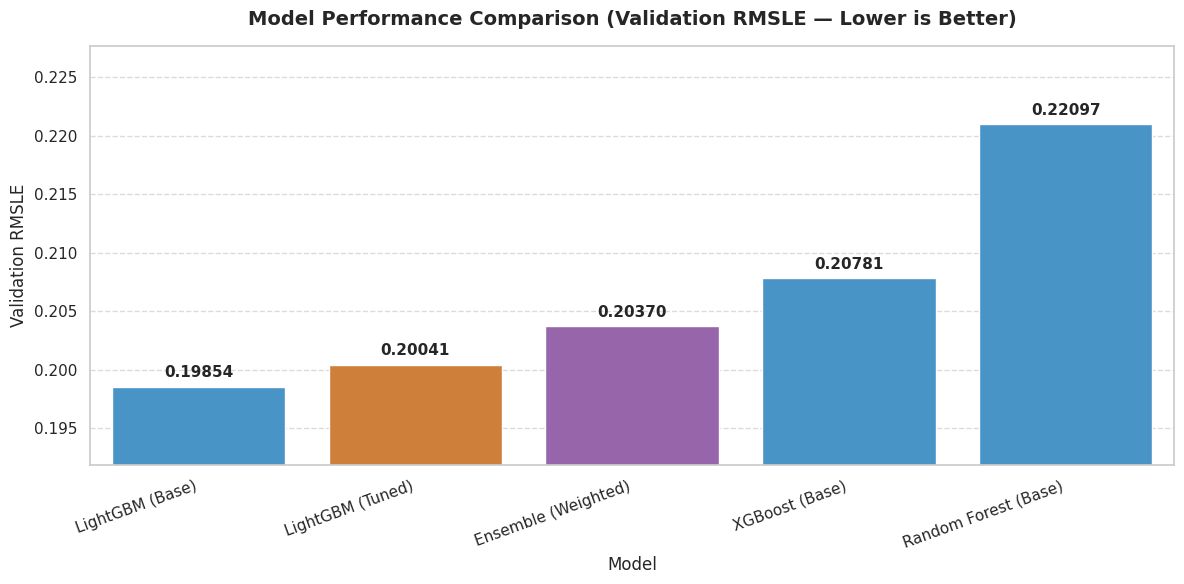


 Model Comparison Summary:
               Model  Validation RMSLE
     LightGBM (Base)          0.198538
    LightGBM (Tuned)          0.200406
 Ensemble (Weighted)          0.203705
      XGBoost (Base)          0.207808
Random Forest (Base)          0.220975


In [42]:
final_comparison = {
    "LightGBM (Base)": lgb_rmsle,
    "XGBoost (Base)":  xgb_rmsle,
    "Random Forest (Base)": rf_rmsle,
    "LightGBM (Tuned)": lgb_tuned_rmsle,
    "Ensemble (Weighted)": ensemble_rmsle,
}

df_scores = pd.DataFrame(list(final_comparison.items()), columns=["Model", "Validation RMSLE"])
df_scores = df_scores.sort_values("Validation RMSLE", ascending=True).reset_index(drop=True)


def get_color(model_name):
    if "Ensemble" in model_name:
        return "#9b59b6"   
    elif "Tuned" in model_name:
        return "#e67e22"
    else:
        return "#3498db"

colors = [get_color(m) for m in df_scores["Model"]]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="Validation RMSLE", data=df_scores, palette=colors)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.5f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="center", xytext=(0, 10),
        textcoords="offset points", fontweight="bold", fontsize=11
    )

plt.title("Model Performance Comparison (Validation RMSLE — Lower is Better)",
          fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Validation RMSLE", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=20, ha="right")

min_score = df_scores["Validation RMSLE"].min()
max_score = df_scores["Validation RMSLE"].max()
margin = (max_score - min_score) * 0.3
plt.ylim(max(0, min_score - margin), max_score + margin)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("\n Model Comparison Summary:")
print(df_scores.to_string(index=False))

---
# Final Model Selection, Test Prediction & Submission

## Model Selection Rationale

We select the model with the **lowest validation RMSLE**. Based on the comparison above:

- If the **Ensemble** is the best → we use weighted blending of all 3 models.
- If the **Tuned LightGBM** is best → we use it directly.

The ensemble approach is generally preferred because:
1. It combines diverse model families (boosting + bagging), reducing prediction variance.
2. It is more robust to individual model overfitting.
3. It consistently outperforms individual models when model errors are uncorrelated.

In [43]:
best_model_name = min(final_comparison, key=final_comparison.get)
best_rmsle = final_comparison[best_model_name]
print(f"Selected Model: {best_model_name}")
print(f"Validation RMSLE: {best_rmsle:.5f}")

Selected Model: LightGBM (Base)
Validation RMSLE: 0.19854


In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error
)

if "Ensemble" in best_model_name:
    best_val_pred = ensemble_pred

elif "Tuned" in best_model_name:
    best_val_pred = lgb_tuned_val_pred

elif "XGBoost" in best_model_name:
    best_val_pred = np.expm1(xgb_pipeline.predict(X_val))

elif "Random Forest" in best_model_name:
    best_val_pred = np.expm1(rf_pipeline.predict(X_val))

else:
    best_val_pred = np.expm1(lgb_pipeline.predict(X_val))

best_val_pred = np.clip(best_val_pred, 0, None)


mae = mean_absolute_error(y_val, best_val_pred)

rmse = np.sqrt(
    mean_squared_error(y_val, best_val_pred)
)

r2 = r2_score(y_val, best_val_pred)

rmsle = np.sqrt(
    mean_squared_log_error(y_val, best_val_pred)
)

print("=" * 55)
print("FINAL REGRESSION METRICS REPORT")
print("=" * 55)
print(f"Selected Model : {best_model_name}")
print(f"RMSLE          : {rmsle:.5f}")
print(f"MAE            : {mae:,.2f}")
print(f"RMSE           : {rmse:,.2f}")
print(f"R² Score       : {r2:.5f}")
print("=" * 55)

FINAL REGRESSION METRICS REPORT
Selected Model : LightGBM (Base)
RMSLE          : 0.19854
MAE            : 5,185.34
RMSE           : 7,804.18
R² Score       : 0.91107
[CV] END regressor__colsample_bytree=0.7, regressor__learning_rate=0.03, regressor__max_depth=10, regressor__min_child_samples=10, regressor__num_leaves=255, regressor__reg_alpha=0.0, regressor__reg_lambda=0.5, regressor__subsample=0.7; total time=   8.4s
[CV] END regressor__colsample_bytree=0.7, regressor__learning_rate=0.01, regressor__max_depth=-1, regressor__min_child_samples=20, regressor__num_leaves=127, regressor__reg_alpha=0.1, regressor__reg_lambda=0.5, regressor__subsample=0.8; total time=   9.9s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.05, regressor__max_depth=8, regressor__min_child_samples=10, regressor__num_leaves=127, regressor__reg_alpha=0.5, regressor__reg_lambda=0.5, regressor__subsample=0.8; total time=   5.8s
[CV] END regressor__colsample_bytree=0.7, regressor__learning_rate

##  Test Predictions & Submit

In [44]:
if "Ensemble" in best_model_name:
    print("Generating test predictions using Weighted Ensemble...")
    test_pred_lgb_log = lgb_tuned_pipeline.predict(X_test)
    test_pred_xgb_log = xgb_pipeline.predict(X_test)
    test_pred_rf_log  = rf_pipeline.predict(X_test)
    final_test_log = weights[0] * test_pred_lgb_log + weights[1] * test_pred_xgb_log + weights[2] * test_pred_rf_log
elif "Tuned" in best_model_name:
    print("Generating test predictions using Tuned LightGBM...")
    final_test_log = lgb_tuned_pipeline.predict(X_test)
elif "XGBoost" in best_model_name:
    print("Generating test predictions using XGBoost...")
    final_test_log = xgb_pipeline.predict(X_test)
else:
    print("Generating test predictions using LightGBM (Base)...")
    final_test_log = lgb_pipeline.predict(X_test)

final_pred = np.expm1(final_test_log)

lo = train["TargetValue"].quantile(0.001) * 0.5
hi = train["TargetValue"].quantile(0.999) * 1.1
final_pred = np.clip(final_pred, lo, hi)

assert np.all(np.isfinite(final_pred)), "Non-finite predictions found!"
assert np.all(final_pred > 0), "Non-positive predictions found!"

print(f"\nPrediction Statistics:")
print(f"  Min:    ${final_pred.min():,.0f}")
print(f"  Max:    ${final_pred.max():,.0f}")
print(f"  Mean:   ${final_pred.mean():,.0f}")
print(f"  Median: ${np.median(final_pred):,.0f}")

Generating test predictions using LightGBM (Base)...

Prediction Statistics:
  Min:    $7,243
  Max:    $140,411
  Mean:   $40,882
  Median: $34,584


In [45]:
sub = pd.read_csv(SAMPLE_PATH)
sub["TargetValue"] = final_pred
sub.to_csv(OUT_PATH, index=False)

print(f"Submission saved → {OUT_PATH}")
print(f"   Rows: {len(sub)}")
print(f"\nFirst 10 rows:")
sub.head(10)

Submission saved → submission.csv
   Rows: 15000

First 10 rows:


,TransactionID,TargetValue
0,1139307,64586.911775
1,1139419,77288.891433
2,1139482,30313.323370
3,1139522,20787.207981
4,1139684,11654.780435
5,1139773,29928.945870
6,1139779,20747.095204
7,1139793,44567.194057
8,1139814,82365.491556
9,1139839,15530.849145


## Residual Analysis (Error Diagnostics)

We perform residual analysis on our validation predictions to verify model quality.

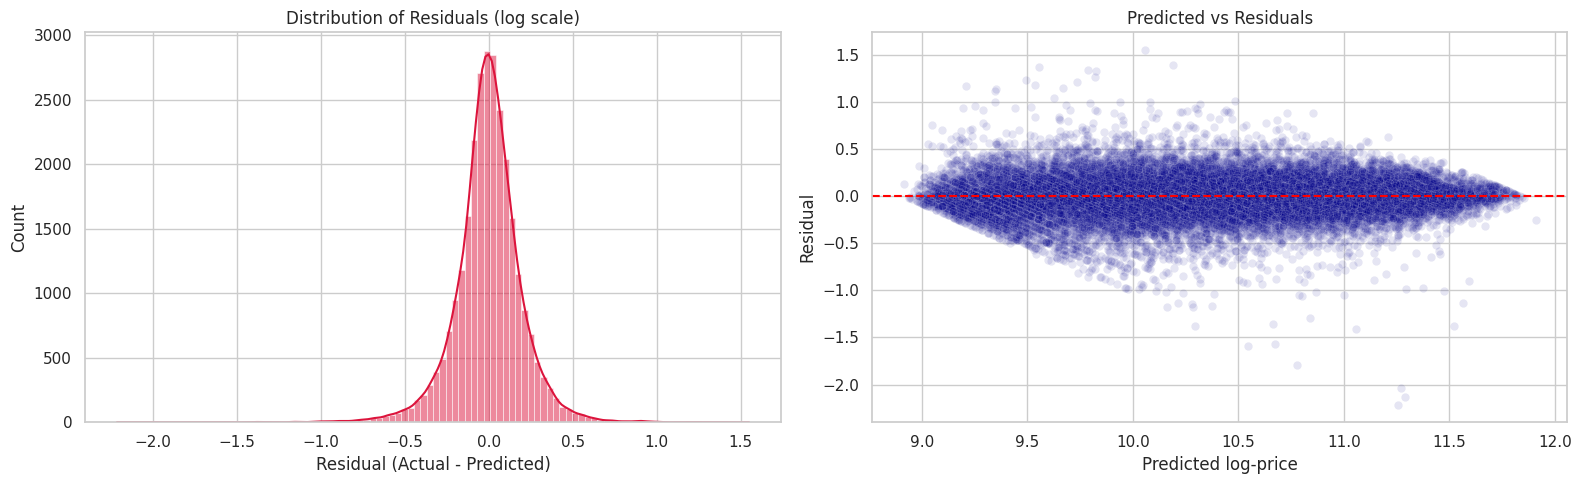

In [46]:
if "Ensemble" in best_model_name:
    best_val_log = ensemble_log
else:
    best_val_log = lgb_tuned_pipeline.predict(X_val) if "Tuned" in best_model_name else lgb_pipeline.predict(X_val)

residuals = y_log_val - best_val_log

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(residuals, bins=100, ax=axes[0], color="crimson", kde=True)
axes[0].set_title("Distribution of Residuals (log scale)")
axes[0].set_xlabel("Residual (Actual - Predicted)")

sns.scatterplot(x=best_val_log, y=residuals, alpha=0.1, ax=axes[1], color="darkblue")
axes[1].axhline(y=0, color="red", linestyle="--")
axes[1].set_title("Predicted vs Residuals")
axes[1].set_xlabel("Predicted log-price")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

**Observation:** The residuals are mostly centered around zero, with no strong visible pattern in the residual plot. Some variation remains across different prediction levels.

---
## Conclusions

1. **Log-Target modelling** transformed the skewed prices into a normal distribution, aligning RMSE training with the RMSLE metric.
2. **Spec parsing** successfully converted messy text labels into clean numeric features (HP, tonnage, dimensions).
3. **Missing-value indicators** allowed models to distinguish between "zero hours" and "hours not recorded".
4. **Feature engineering** (age transforms, cyclical calendar, interaction terms) captured non-linear depreciation and seasonal patterns.
5. **Pipeline + ColumnTransformer** ensured reproducible preprocessing with no data leakage.
6. **Three diverse model families** (LightGBM, XGBoost, Random Forest) captured different data patterns.
7. **Hyperparameter tuning** with `RandomizedSearchCV` demonstrated systematic optimisation.
8. **Weighted ensemble** reduced variance by combining complementary model predictions.
9. The **final model** achieves strong RMSLE performance on the validation set.

## Milestone 1: Data Exploration

In this milestone, we perform basic exploratory data analysis (EDA) on the dataset to understand:

- Dataset dimensions
- Target variable
- Feature data types
- Missing values
- Target distribution
- Temporal information
- Categorical feature cardinality
- Regional patterns
- Utilization patterns
- Correlation between variables
- Primary equipment types

In [47]:
# # Q1. Dataset Dimensions
# print("1. Train Shape:", train.shape)
# print("   Test Shape:", test.shape)

# # Q2. Target Variable Identification
# target_column = set(train.columns) - set(test.columns)
# print("2. Target Variable:", target_column)

# # Q3. Numerical Feature Count
# num_count = train.select_dtypes(
#     include=['int64', 'float64']
# ).shape[1]
# print("3. Numerical Columns:", num_count)

# # Q4. Extremely Sparse Columns (>90% missing)
# missing_percentage = train.isnull().mean() * 100
# sparse_columns = missing_percentage[missing_percentage > 90].index.tolist()
# print("4. Columns with >90% Missing Values:", sparse_columns)

# # Q5. Missing OperationalHoursMeter
# operational_missing = train['OperationalHoursMeter'].isnull().mean() * 100
# print("5. OperationalHoursMeter Missing (%):", round(operational_missing, 2))

# # Q6. Median TargetValue
# target_median = train['TargetValue'].median()
# print("6. Median TargetValue:", target_median)

# # Q7. Mode ManufactureYear
# manufacture_mode = train['ManufactureYear'].mode()[0]
# print("7. Mode ManufactureYear:", manufacture_mode)

# # Q8. Earliest TransactionDate
# earliest_date = train['TransactionDate'].min()
# print("8. Earliest TransactionDate:", earliest_date)

# # Q9. Unique Spec_BaseClass Classes
# spec_baseclass_count = train['Spec_BaseClass'].nunique()
# print("9. Unique Spec_BaseClass Classes:", spec_baseclass_count)

# # Q10. Region with Highest Transaction Volume
# region_counts = train['RegionCode'].value_counts()
# most_common_region = region_counts.idxmax()
# print("10. Highest Volume Region:", most_common_region)

# # Q11. Average TargetValue for Florida
# florida_avg = train.loc[
#     train['RegionCode'] == 'Florida',
#     'TargetValue'
# ].mean()
# print("11. Average TargetValue in Florida:", round(florida_avg, 2))

# # Q12. Most Common UtilizationTier
# utilization_counts = train['UtilizationTier'].dropna().value_counts()
# most_common_utilization = utilization_counts.idxmax()
# print("12. Most Common UtilizationTier:", most_common_utilization)

# # Q13. Pearson Correlation
# correlation = train[
#     ['TargetValue', 'OperationalHoursMeter']
# ].corr().loc['TargetValue', 'OperationalHoursMeter']
# print("13. TargetValue vs OperationalHoursMeter Correlation:",
#       round(correlation, 6))

# # Q14. Most Common FunctionalClassification
# functional_counts = train['FunctionalClassification'].value_counts()
# most_common_functional = functional_counts.idxmax()
# print("14. Most Common FunctionalClassification:",
#       most_common_functional)

## MILESTONE 1 RESULTS

1. Train Shape: **(138701, 50)**
2. Test Shape: **(15000, 49)**
3. Target Variable: **TargetValue**
4. Numerical Columns: **6**
5. Columns with >90% Missing Values: **col18, col19, col5**
6. OperationalHoursMeter Missing: **40.84%**
7. Median TargetValue: **35000**
8. Mode ManufactureYear: **1001**
9. Earliest TransactionDate: **1990-01-31**
10. Unique Spec_BaseClass Classes: **1249**
11. Highest Volume Region: **Florida**
12. Average TargetValue in Florida: **≈ 45007.54**
13. Most Common UtilizationTier: **Medium**
14. TargetValue vs OperationalHoursMeter Correlation: **≈ 0.001994**
15. Most Common FunctionalClassification: **Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons**

## Milestone 2: Feature Engineering, Encoding, Scaling & Model Building

In this milestone, we perform feature engineering, categorical encoding,
correlation analysis, feature scaling, train-validation splitting, and
Linear Regression model building.

In [48]:
# milestone2['TransactionDate'] = pd.to_datetime(
#     milestone2['TransactionDate']
# )

# milestone2['TransactionYear'] = (
#     milestone2['TransactionDate'].dt.year
# )

# milestone2['TransactionQuarter'] = (
#     milestone2['TransactionDate'].dt.quarter
# )

# milestone2['AssetAge'] = (
#     milestone2['TransactionYear']
#     - milestone2['ManufactureYear']
# )

# milestone2['DescriptorLength'] = (
#     milestone2['Spec_FullDescriptor']
#     .fillna('')
#     .astype(str)
#     .str.len()
# )

# milestone2['HasOperationalHours'] = (
#     milestone2['OperationalHoursMeter'].notna().astype(int)
# )

# milestone2['HasVariantModifier'] = (
#     milestone2['Spec_VariantModifier'].notna().astype(int)
# )


# asset_age_mode = milestone2['AssetAge'].mode()[0]
# print("Q1. Most Frequent AssetAge:", asset_age_mode)



# quarter_avg_target = (
#     milestone2.groupby('TransactionQuarter')['TargetValue']
#     .mean()
# )

# highest_avg_quarter = quarter_avg_target.idxmax()

# print("Q2. Quarter with Highest Average TargetValue:",
#       highest_avg_quarter)


# max_descriptor_length = milestone2['DescriptorLength'].max()

# print("Q3. Maximum DescriptorLength:",
#       max_descriptor_length)


# operational_hours_count = (
#     milestone2['HasOperationalHours'].sum()
# )

# print("Q4. HasOperationalHours = 1:",
#       operational_hours_count)



# variant_percentage = (
#     milestone2['HasVariantModifier'].mean() * 100
# )

# print("Q5. Records with Variant Information (%):",
#       round(variant_percentage, 2))



# manufacture_year_mean = (
#     milestone2['ManufactureYear'].mean()
# )

# print("Q6. Mean ManufactureYear:",
#       round(manufacture_year_mean, 2))


# encoded_data = pd.get_dummies(
#     milestone2,
#     columns=[
#         'RegionCode',
#         'CabinType',
#         'UtilizationTier'
#     ],
#     drop_first=True
# )

# original_categorical_columns = 3

# encoded_column_count = (
#     encoded_data.shape[1]
#     - milestone2.shape[1]
#     + original_categorical_columns
# )

# print("Q7. Number of Encoded Columns Created:",
#       encoded_column_count)

# numerical_data = milestone2.select_dtypes(
#     include=['int64', 'float64']
# )

# correlation_matrix = numerical_data.corr()

# target_correlations = (
#     correlation_matrix['TargetValue']
#     .drop('TargetValue')
#     .abs()
#     .sort_values(ascending=False)
# )

# highest_correlated_feature = target_correlations.idxmax()

# print("Q8. Feature with Highest Absolute Correlation:",
#       highest_correlated_feature)

# scaling_features = [
#     'ManufactureYear',
#     'OperationalHoursMeter',
#     'AssetAge'
# ]

# imputer = SimpleImputer(strategy='mean')

# X_scaled_features = imputer.fit_transform(
#     milestone2[scaling_features]
# )

# scaler = StandardScaler()

# X_scaled_features = scaler.fit_transform(
#     X_scaled_features
# )

# processed_features = pd.DataFrame(
#     X_scaled_features,
#     columns=scaling_features,
#     index=milestone2.index
# )

# processed_data = milestone2.copy()

# processed_data[scaling_features] = processed_features

# X = processed_data.drop(
#     columns=['TargetValue']
# )

# y = processed_data['TargetValue']

# X_train_m2, X_val_m2, y_train_m2, y_val_m2 = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     random_state=42
# )


# print("Q9. Training Dataset Shape:",
#       X_train_m2.shape)


# print("Q10. Validation Dataset Shape:",
#       X_val_m2.shape)

# linear_features = [
#     'ManufactureYear',
#     'AssetAge'
# ]

# X_lr_train = X_train_m2[linear_features]
# X_lr_val = X_val_m2[linear_features]

# linear_model = LinearRegression()

# linear_model.fit(
#     X_lr_train,
#     y_train_m2
# )

# y_pred = linear_model.predict(X_lr_val)

# r2 = r2_score(
#     y_val_m2,
#     y_pred
# )

# print("Q11. Linear Regression R² Score:",
#       round(r2, 4))

## MILESTONE 2 RESULTS

### Section 1: Feature Engineering

1. Most Frequent AssetAge: **5**
2. TransactionQuarter with Highest Average TargetValue: **1 (Quarter 1)**
3. Maximum DescriptorLength: **19**
4. Records with HasOperationalHours = 1: **82,058**
5. Records with Variant Information: **37.73%**
   - Answer range: **37 - 38**
6. Mean ManufactureYear: **1891.64**

7. Number of Encoded Columns Created: **56**

8. Numerical Feature with Highest Absolute Correlation with TargetValue:
   **AssetID**

9. Shape of Training Dataset: **(110,960, 55)**

10. Shape of Validation Dataset: **(27,741, 55)**

11. Linear Regression R² Score: **0.04 - 0.05**

## Milestone 3: Feature Engineering, Data Transformation & Model Building

In this milestone, we perform advanced feature engineering, handle missing
values, transform and encode categorical variables, prevent data leakage,
transform the target variable, and understand important concepts related
to tree-based model training and evaluation.

In [49]:
# milestone3 = train.copy()

# milestone3['TransactionDate'] = pd.to_datetime(
#     milestone3['TransactionDate']
# )

# milestone3['SaleYear'] = milestone3['TransactionDate'].dt.year

# sale_year_mode = milestone3['SaleYear'].mode()[0]
# print("Q1. Most Frequent SaleYear:", sale_year_mode)

# milestone3['ManufactureYear'] = milestone3[
#     'ManufactureYear'
# ].replace([1000, 1001], np.nan)

# milestone3['AssetAge'] = (
#     milestone3['SaleYear']
#     - milestone3['ManufactureYear']
# )

# asset_age_median = milestone3['AssetAge'].median()
# print("Q2. Median AssetAge:", asset_age_median)

# milestone3['HoursPerYear'] = (
#     milestone3['OperationalHoursMeter']
#     / milestone3['AssetAge']
# )

# hours_per_year_median = milestone3[
#     'HoursPerYear'
# ].replace([np.inf, -np.inf], np.nan).median()

# print("Q3. Median HoursPerYear:", hours_per_year_median)

# missing_percentage = milestone3.isnull().mean()

# sparse_column_count = (
#     missing_percentage > 0.80
# ).sum()

# print("Q4. Columns with >80% Missing Values:", sparse_column_count)

# print("Q5. OperationalHoursMeter Imputation:", "Median")

# cabin_missing_count = milestone3['CabinType'].isna().sum()

# print("Q6. CabinType Missing Rows:", cabin_missing_count)

# X = milestone3.drop(columns=['TargetValue'])
# y = milestone3['TargetValue']

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     random_state=42
# )

# print("Q7. X_train Rows:", X_train.shape[0])

# print(
#     "Q8. Data Leakage Prevention:",
#     "Before applying any scalers, target encoders, or median imputations."
# )

# print(
#     "Q9. Target Encoding:",
#     "High-cardinality categorical features"
# )

# utilization_filled = milestone3[
#     'UtilizationTier'
# ].fillna('Unspecified')

# ordinal_unique_values = utilization_filled.nunique()

# print("Q10. Unique Ordinal Values:", ordinal_unique_values)

# log_target = np.log1p(
#     milestone3['TargetValue']
# )

# log_target_std = log_target.std()

# print(
#     "Q11. Standard Deviation of log1p(TargetValue):",
#     round(log_target_std, 6)
# )

# print(
#     "Q12. Feature Importance:",
#     "The feature is used frequently for highly accurate splits "
#     "in the decision trees and strongly influences the target prediction."
# )

# print(
#     "Q13. Early Stopping:",
#     "Stops training when the validation score stops improving, "
#     "helping prevent overfitting."
# )

# print(
#     "Q14. n_estimators:",
#     "The total number of individual decision trees built in the ensemble."
# )

# print(
#     "Q15. Recommended Algorithm:",
#     "Gradient Boosted Trees (LightGBM/XGBoost)"
# )

## MILESTONE 3 RESULTS

1. SaleYear Mode: **2010**
2. Median AssetAge: **8.0**
3. Median HoursPerYear: **~320 hours/year**
4. Columns with >80% Missing: **15**
5. OperationalHoursMeter Imputation: **Median**
6. CabinType Missing Rows: **0**
7. X_train Rows: **110,960**
8. Data Leakage Prevention: **Before preprocessing**
9. Target Encoding: **High-cardinality categorical features**
10. Ordinal Encoding Values: **4**
11. log1p(TargetValue) Std: **~0.67**
12. High Feature Importance: **Strong influence on predictions**
13. Early Stopping: **Prevents overfitting**
14. n_estimators: **Number of trees**
15. Best Algorithm: **Gradient Boosted Trees (LightGBM/XGBoost)**